In [203]:
from kagome_24_nn_2023_01_30 import (
    experiment_dir,
    fourier_learners_cache_dir,
    ground_state_cache_dir,
    nn_checkpoints_dir,
    nn_accuracy_file,
    nn_overlap_file,
    system_accuracy_file,
    system_overlap_file,
    model_evaluation_file,
    lattice,
    signal_kind,
    FC1SpinNN,
)
import pandas as pd
import seaborn as sns
from heisenberg_hamiltonians import HeisenbergJ1J2
import torch
import torch.nn as nn
import torch.optim as optim
from lattice_boolean_analysis import (
    LBFFromNN,
    LBFFromSpinSystem,
    LatticeBooleanAnalyzer,
    LBATruncation,
    keep_largest_n,
)
import numpy as np
from spin_lattices import SpinLattice
import matplotlib.pyplot as plt
from parity import popcount
import seaborn as sns


In [157]:
%matplotlib inline

In [159]:
model_evaluation = pd.read_csv(model_evaluation_file)


In [160]:
model_evaluation


,J2,eps_train,test_accuracy,test_sign_overlap
0,0.0,0.001,0.948066,0.941971
1,0.0,0.010,0.994497,0.994401
2,0.4,0.001,0.895513,0.856414
3,0.4,0.010,0.990870,0.988444
4,0.6,0.001,0.597794,0.263408
5,0.6,0.010,0.803277,0.722781
6,0.8,0.001,0.530367,0.121732


In [173]:
model_evaluation["nn_analyzer"] = None

for i, (J2, eps_train, accuracy_test, sign_overlap_test) in model_evaluation.iloc[
    :, :4
].iterrows():
    system = HeisenbergJ1J2(
        lattice=lattice,
        J1=1,
        J2=J2,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=ground_state_cache_dir,
        show_progress=True,
    )
    system.get_eigenstates(1)
    model_path = (
        nn_checkpoints_dir
        / f"FC1SpinNN-1hidden-64-sign-{system.system_id()}_eps_train={eps_train}.pt"
    )
    net = FC1SpinNN(lattice=system.lattice, hidden_size=64)
    net.load_state_dict(torch.load(model_path))

    nn_signal = LBFFromNN(
        lattice=lattice,
        nn=net,
        probs=system.get_df_ground_state(canonical_basis=True).assign(
            prob=lambda df: np.abs(df["eigenstate_coeff"]) ** 2
        )["prob"],
        network_id=str(model_path).replace("/", "_"),
    )

    nn_analyzer = LatticeBooleanAnalyzer(
        signal=nn_signal, show_progress=True, cache_dir=fourier_learners_cache_dir
    )
    try:
        nn_analyzer.fit(from_cache_only=True)
        model_evaluation.loc[i, "nn_analyzer"] = nn_analyzer
    except ValueError as e:
        print(f"Could not fit {model_path}")
        print(e)
        continue

    print(f"{J2!r},{eps_train},{accuracy_test},{sign_overlap_test}")

system_analyzers = {}
for J2 in model_evaluation["J2"].unique():
    system = HeisenbergJ1J2(
        lattice=lattice,
        J1=1,
        J2=J2,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=ground_state_cache_dir,
        show_progress=True,
    )
    system.get_eigenstates(1)
    system_signal = LBFFromSpinSystem(system=system, eigenstate=0, kind=signal_kind)
    system_analyzer = LatticeBooleanAnalyzer(
        signal=system_signal, show_progress=True, cache_dir=fourier_learners_cache_dir
    )
    try:
        system_analyzer.fit(from_cache_only=True)
        system_analyzers[J2] = system_analyzer
    except ValueError as e:
        print(f"Could not fit {J2}")
        print(e)
        continue
system_analyzers = pd.Series(system_analyzers).to_frame()


number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
Ground state energy is -46.1341392314
Restoring learner from cache: fourier_learners_cache/5931578d37751707383611df6b2a7833-experiments_kagome_24_nn_2023_01_30_nn_checkpoints_FC1SpinNN-1hidden-64-sign-HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1_eps_train=0.001.pt-KagomeLattice2x4.lz
0.0,0.001,0.9480664352999504,0.9419708251953124
number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
Ground state energy is -46.1341392314
Restoring learner from cache: fourier_learners_cache/1b325b98d58c98e94d628d68602faa19-experiments_kagome_24_nn_2023_01_30_nn_checkpoints_FC1SpinNN-1hidden-64-sign-HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1

In [97]:
model_evaluation


,J2,eps_train,test_accuracy,test_sign_overlap,nn_analyzer
0,0.0,0.001,0.948066,0.941971,<lattice_boolean_analysis.LatticeBooleanAnalyz...
1,0.0,0.010,0.994497,0.994401,<lattice_boolean_analysis.LatticeBooleanAnalyz...
2,0.4,0.001,0.895513,0.856414,<lattice_boolean_analysis.LatticeBooleanAnalyz...
3,0.4,0.010,0.990870,0.988444,<lattice_boolean_analysis.LatticeBooleanAnalyz...
4,0.6,0.001,0.597794,0.263408,<lattice_boolean_analysis.LatticeBooleanAnalyz...
5,0.6,0.010,0.803277,0.722781,<lattice_boolean_analysis.LatticeBooleanAnalyz...


In [166]:
nn_terms = pd.read_csv(nn_accuracy_file).assign(
    terms=lambda x: pd.to_numeric(x["terms"], errors="coerce")
)


In [167]:
nn_terms


,J2,terms,accuracy,sign_overlap
0,0.0,1,0.875254,0.931807
1,0.0,1,0.988174,0.993827
2,0.4,1,0.828468,0.861013
3,0.4,1,0.976951,0.991016
4,0.6,11,0.817269,0.215375
5,0.6,41,0.709801,0.844038


In [168]:
system_terms = pd.read_csv(system_accuracy_file).assign(
    terms=lambda x: pd.to_numeric(x["terms"], errors="coerce")
)


In [169]:
system_terms


,J2,terms,accuracy,sign_overlap
0,0.0,1,1.000000,1.000000
1,0.4,1,0.973059,0.999994
2,0.6,61,0.705711,0.935757


In [171]:
def total_hamming_weight(analyzer: LatticeBooleanAnalyzer, terms: int) -> int:
    return popcount(np.asarray(analyzer.learner.get_coeffs_ser().iloc[:terms].index)).sum()


In [176]:
model_evaluation.dropna()


,J2,eps_train,test_accuracy,test_sign_overlap,nn_analyzer
0,0.0,0.001,0.948066,0.941971,<lattice_boolean_analysis.LatticeBooleanAnalyz...
1,0.0,0.010,0.994497,0.994401,<lattice_boolean_analysis.LatticeBooleanAnalyz...
2,0.4,0.001,0.895513,0.856414,<lattice_boolean_analysis.LatticeBooleanAnalyz...
3,0.4,0.010,0.990870,0.988444,<lattice_boolean_analysis.LatticeBooleanAnalyz...
4,0.6,0.001,0.597794,0.263408,<lattice_boolean_analysis.LatticeBooleanAnalyz...
5,0.6,0.010,0.803277,0.722781,<lattice_boolean_analysis.LatticeBooleanAnalyz...


In [188]:
def add_complexity_measures(df, analyzer_column="analyzer"):
    return (df.assign(
        hamming_weight=lambda df: df.apply(
            lambda row: total_hamming_weight(row[analyzer_column], int(row["terms"])), axis=1
        ),
        number_spins=lambda df: df[analyzer_column].apply(lambda a: a.number_spins),
    )
    .assign(
        mean_hw=lambda df: df["hamming_weight"] / df["terms"],
    ))

In [192]:
nn_complexity = add_complexity_measures(
    model_evaluation.dropna()
    .join(nn_terms.drop("J2", axis=1)),
    analyzer_column="nn_analyzer",
)


In [184]:
system_analyzers: pd.Series

In [193]:
system_complexity = add_complexity_measures(
    system_analyzers.reset_index()
    .rename(columns={"index": "J2", 0: "analyzer"})
    .merge(system_terms, on="J2")
)


In [211]:
compare_complexities = pd.concat(
    [
        nn_complexity.assign(signal="nn")
        .rename(columns={"nn_analyzer": "analyzer"})
        .query("eps_train == 0.01"),
        system_complexity.assign(signal="system"),
    ]
).drop(["test_accuracy", "test_sign_overlap"], axis=1)


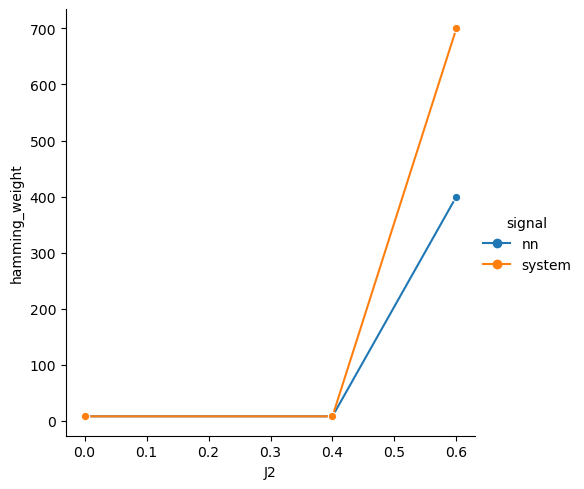

In [212]:
sns.relplot(
    compare_complexities,
    x="J2",
    y="hamming_weight",
    hue="signal",
    style="signal",
    kind="line",
    markers=["o", "o"],
    dashes=False,
)


In [148]:
def visualize_terms(truncation: LBATruncation):
    terms = truncation.truncate_strategy(truncation.analyzer.learner.get_coeffs_ser())
    fig, axes = plt.subplots(1, len(terms), figsize=(len(terms) * 3, 3), squeeze=False)
    for subset, term, ax in zip(terms.index, terms, axes[0]):
        truncation.analyzer.lattice.plot(spins=subset, ax=ax)
        # ax.set_title(f"{term:.2f}")
        # ax.axis('off')
        ax.set_xlabel(f"coeff = {term:.2f}")
        ax.set_ylabel("")
    plt.tight_layout()


In [149]:
nn_terms.assign(terms=lambda x: pd.to_numeric(x["terms"], errors="coerce"))

,J2,terms,accuracy,sign_overlap
0,0.0,421.0,0.948220,0.950176
1,0.0,1.0,0.988174,0.993827
2,0.4,1841.0,0.961801,0.950368
3,0.4,1.0,0.976951,0.991016
4,0.6,NaN,0.960177,0.903340
5,0.6,1261.0,0.849713,0.950088


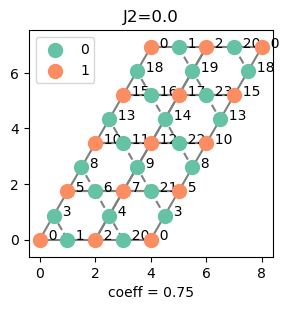

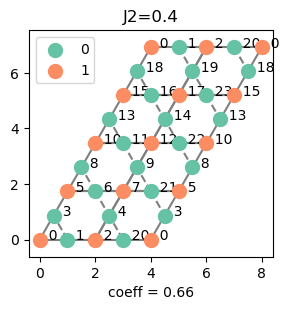

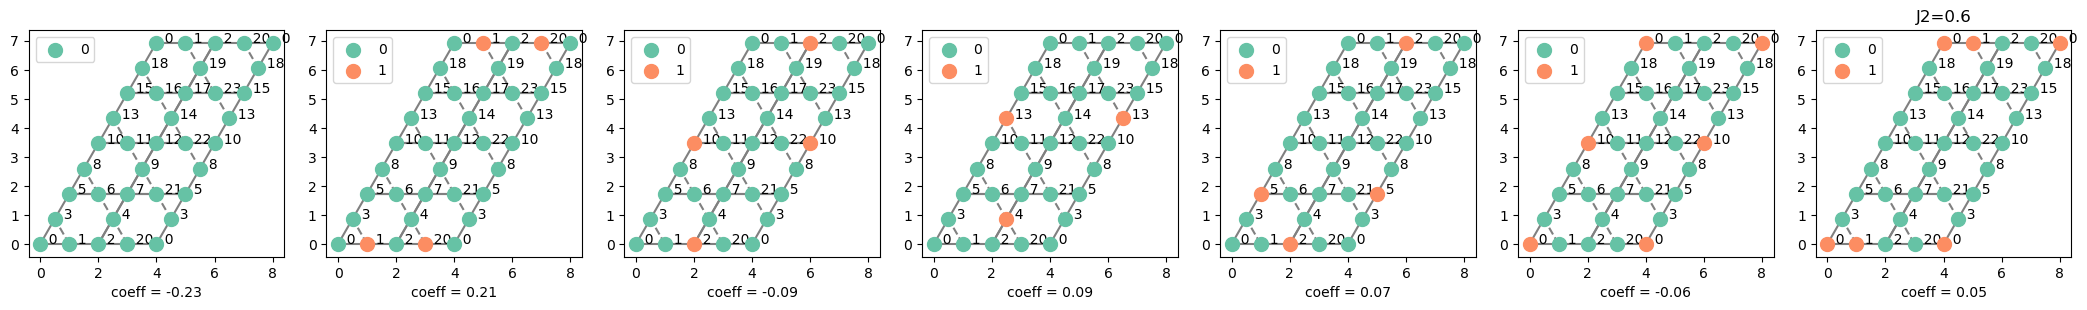

AttributeError: 'NoneType' object has no attribute 'truncate'

In [215]:
max_subsets = 7
eps_train = 0.001

for _, row in (
    model_evaluation.join(nn_terms.drop("J2", axis=1)).query("eps_train == @eps_train").iterrows()
):
    visualize_terms(
        row["nn_analyzer"].truncate(
            keep_largest_n(
                int(min(max_subsets, row["terms"])) if not np.isnan(row["terms"]) else max_subsets
            )
        )
    )
    plt.title(f"J2={row['J2']}")
    plt.show()
